# **House Rent Prediction In India by Scikit-Learn Library**
Objective:
The objective of applying machine learning algorithms using the Scikit-Learn library on a dataset for house rent prediction in India is to create a predictive model that can accurately estimate the rental price of a house based on various features such as location, size, number of bedrooms, amenities, and more. The aim is to provide potential tenants and real estate professionals with a reliable tool to gauge appropriate rental prices, thereby aiding in decision-making processes and ensuring fair market values.

**About Dataset:**
Within this dataset, you will find a comprehensive collection of data pertaining to nearly 4700+ available residential properties, encompassing houses, apartments, and flats offered for rent. This dataset is rich with various attributes, including the number of bedrooms (BHK), rental rates, property size, number of floors, area type, locality, city, furnishing status, tenant preferences, bathroom count, and contact information for the respective point of contact.

**Dataset Glossary (Column-Wise)**
BHK: Number of Bedrooms, Hall, Kitchen.

1.   Rent: Rent of the Houses/Apartments/Flats.
Size: Size of the Houses/Apartments/Flats in Square Feet.
2.   Floor: Houses/Apartments/Flats situated in which Floor and Total Number of Floors (Example: Ground out of 2, 3 out of 5, etc.)
3.   Area Type: Size of the Houses/Apartments/Flats calculated on either Super Area or Carpet Area or Build Area.
4.   Area Locality: Locality of the Houses/Apartments/Flats.
5.   City: City where the Houses/Apartments/Flats are Located.
6.  Furnishing Status: Furnishing Status of the Houses/Apartments/Flats, either it is Furnished or Semi-Furnished or Unfurnished.
7.  Tenant Preferred: Type of Tenant Preferred by the Owner or Agent.
8.  Bathroom: Number of Bathrooms.
9.  Point of Contact: Whom should you contact for more information regarding the Houses/Apartments/Flats.

**# Dataset link:**
https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset/data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/House_Rent_Dataset.csv")
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [3]:
# Understanding the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BHK,4746.0,2.083860,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Bathroom,4746.0,1.965866,0.884532,1.0,1.0,2.0,2.0,10.0


In [5]:
val_cat = df.select_dtypes(exclude= np.number).columns
val_num = df.select_dtypes(include=np.number).columns

In [6]:
print(val_cat)
print(val_num)

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object')
Index(['BHK', 'Rent', 'Size', 'Bathroom'], dtype='object')


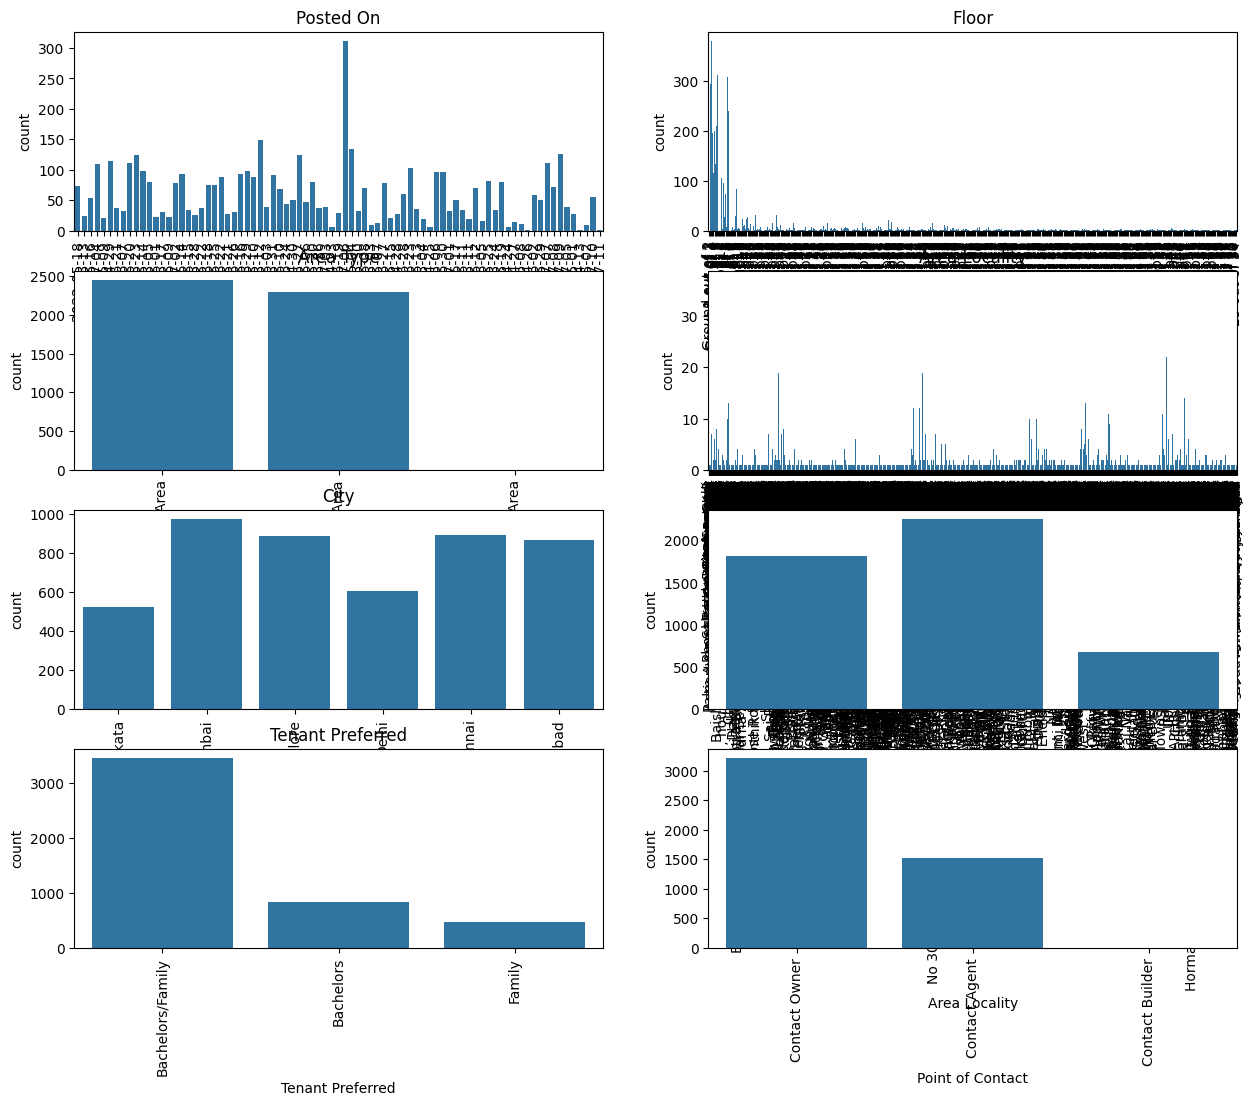

In [7]:
# EDA
# plot graph for all the columns
plt.figure(figsize=(15,15))
a = 5
b = 2
c = 1
for i in val_cat:
  plt.subplot(a,b,c)
  sns.countplot(data = df, x = df[i])
  plt.title(i)
  plt.xticks(rotation= 90)
  c += 1
plt.tight_layout()
plt.show()

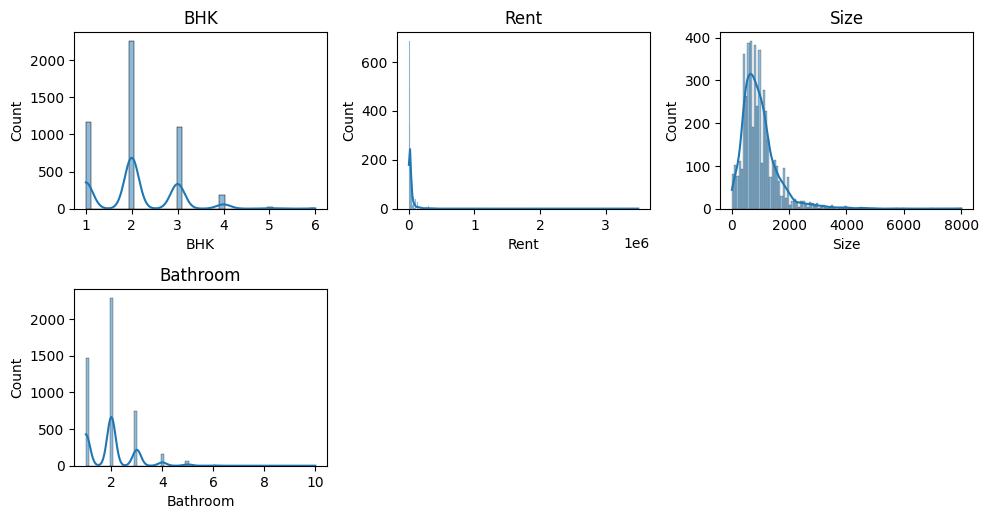

In [8]:
# EDA
# plot graph for all the columns
a = 4
b = 3
plt.figure(figsize=(10,10))
c = 1
for i in val_num:
  plt.subplot(a,b,c)
  sns.histplot(data = df, x = df[i], kde= True)
  plt.title(i)
  c += 1
plt.tight_layout()
plt.show()

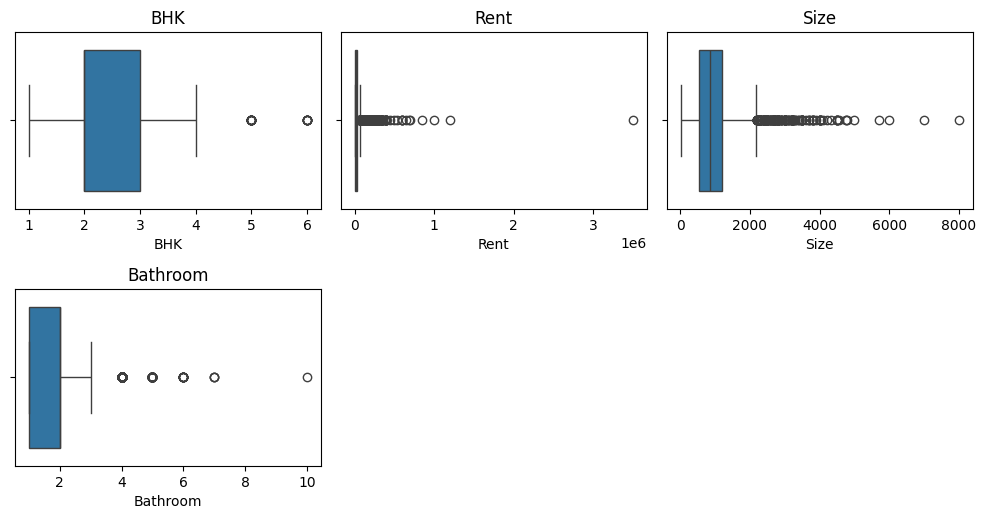

In [9]:
# detecting the outliers
a = 4
b = 3
plt.figure(figsize=(10,10))
c = 1
for i in val_num:
  plt.subplot(a,b,c)
  sns.boxplot(data = df, x = df[i])
  plt.title(i)
  c += 1
plt.tight_layout()
plt.show()

In [10]:
df.isnull().sum()

,0
Posted On,0
BHK,0
Rent,0
Size,0
Floor,0
Area Type,0
Area Locality,0
City,0
Furnishing Status,0
Tenant Preferred,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='object')

In [13]:
df['Posted On'] = pd.to_datetime(df['Posted On'])
df["Year"] = df["Posted On"].dt.year

In [14]:
# Feature Engineering
# Feature creation
df["HouseAge"] = 2026 - df["Year"]

In [15]:
df.drop(["Posted On", "Year"], axis= 1, inplace= True)
df.head()

,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,HouseAge
0,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,4
1,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,4
2,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,4
3,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,4
4,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,4


In [16]:
print(df["Floor"])

0       Ground out of 2
1            1 out of 3
2            1 out of 3
3            1 out of 2
4            1 out of 2
             ...       
4741         3 out of 5
4742         1 out of 4
4743         3 out of 5
4744       23 out of 34
4745         4 out of 5
Name: Floor, Length: 4746, dtype: object


In [17]:
df["TotalFloor"] = df["Floor"].str.split(" out of ", expand= True)[1]

In [18]:
df["CurrentFloor"] = df["Floor"].str.split(" out of ", expand= True)[0]

In [19]:
df["CurrentFloor"].unique()

array(['Ground', '1', '2', '4', '3', '5', '7', '8', 'Upper Basement',
       '11', 'Lower Basement', '6', '14', '43', '13', '18', '17', '9',
       '19', '60', '34', '12', '26', '25', '53', '16', '10', '39', '32',
       '47', '28', '20', '15', '65', '40', '37', '22', '21', '30', '35',
       '33', '44', '41', '46', '27', '45', '48', '50', '24', '23', '29',
       '49', '36', '76'], dtype=object)

In [20]:
df["CurrentFloor"] = df["CurrentFloor"].replace({"Ground": 0,
                                                 "Upper Basement": -1,
                                                 "Lower Basement": -2})

In [21]:
df["TotalFloor"].unique()

array(['2', '3', '1', '4', '5', '14', '8', '6', '19', '10', '7', '13',
       '78', '18', '12', '24', '31', '21', '23', '20', '9', '22', '58',
       '16', '66', '48', '40', '44', '42', '41', '60', '32', '30', '29',
       '89', '15', '11', '28', '17', '45', '35', '75', '38', '51', '43',
       '25', '27', '26', '76', '36', '37', '55', '68', '77', '50', '59',
       '62', '39', '52', '54', '33', '46', '85', '71', '81', '34', None],
      dtype=object)

In [22]:
df["TotalFloor"] = df["TotalFloor"].fillna(1).astype(int)
df["CurrentFloor"] = df["CurrentFloor"].astype(int)

In [23]:
df["FloorRatio"] = df["CurrentFloor"]/df["TotalFloor"]

In [24]:
df.drop(["Floor", "TotalFloor", "CurrentFloor"], axis= 1, inplace= True)
df.drop("Point of Contact", axis= 1, inplace= True)

In [25]:
df.head()

,BHK,Rent,Size,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,HouseAge,FloorRatio
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,4,0.000000
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,4,0.333333
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,4,0.333333
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,4,0.500000
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,4,0.500000


In [26]:
df["Bathroom"].unique()

array([ 2,  1,  3,  5,  4,  6,  7, 10])

In [27]:
df.drop("Area Locality", axis=1, inplace= True)

In [28]:
df.drop("Area Type", axis= 1, inplace= True)

In [29]:
df["City"].unique()

array(['Kolkata', 'Mumbai', 'Bangalore', 'Delhi', 'Chennai', 'Hyderabad'],
      dtype=object)

In [30]:
df['Tenant Preferred'].unique()

array(['Bachelors/Family', 'Bachelors', 'Family'], dtype=object)

In [31]:
df['Furnishing Status'].value_counts()

,count
Furnishing Status,
Semi-Furnished,2251
Unfurnished,1815
Furnished,680


In [32]:
df = pd.get_dummies(df,
                    columns=["City","Tenant Preferred"],
                    drop_first=True, dtype = int)

In [33]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Furnishing Status"] = le.fit_transform(df["Furnishing Status"])

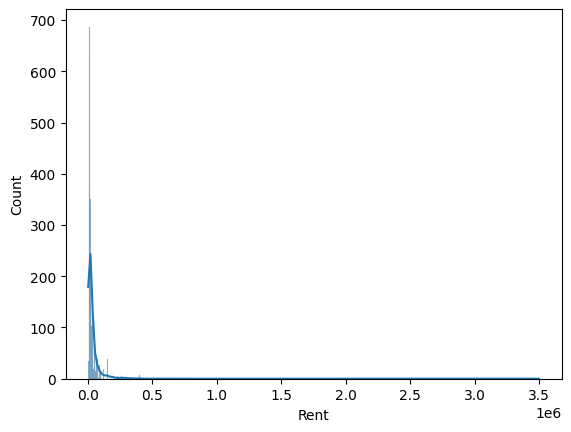

In [34]:
sns.histplot(data= df, x= "Rent", kde= True)
plt.show()

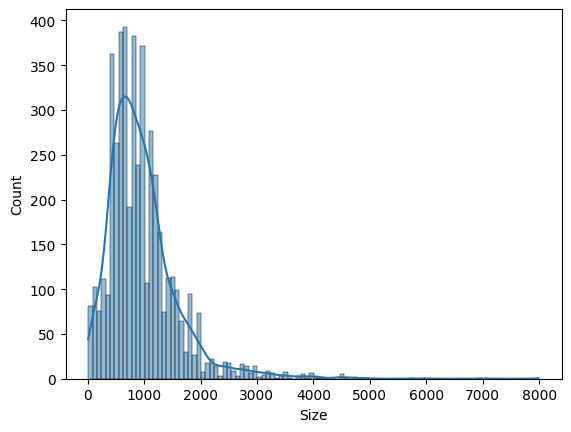

In [35]:
sns.histplot(data= df, x= "Size", kde= True)
plt.show()

In [36]:
print(df[['Rent', 'Size']].skew())

Rent    21.409942
Size     2.299892
dtype: float64


In [37]:
import numpy as np

df["Rent"] = np.log1p(df["Rent"])

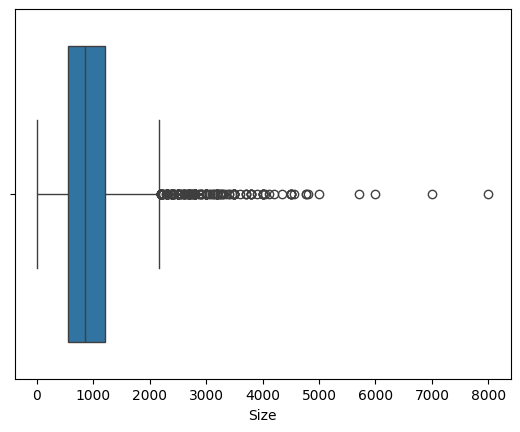

In [38]:
sns.boxplot(data= df, x= "Size")
plt.show()

In [39]:
# IQR
Q1 = df["Size"].quantile(0.25)
Q3 = df["Size"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Size"] < lower) | (df["Size"] > upper)]

print(len(outliers))
print("Number of outliers:", len(outliers))
print("Percentage:", (len(outliers)/len(df))*100)

203
Number of outliers: 203
Percentage: 4.277286135693215


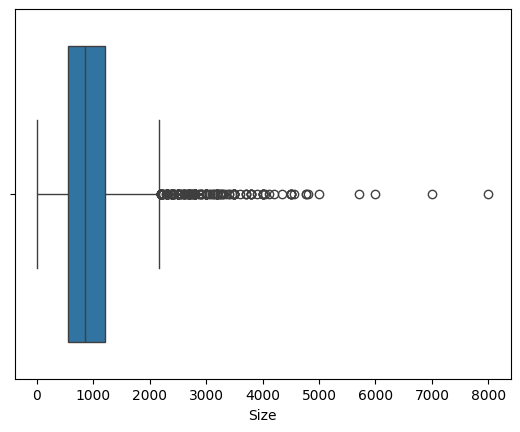

In [40]:
sns.boxplot(data= df, x= "Size")
plt.show()

In [41]:
df.head()

,BHK,Rent,Size,Furnishing Status,Bathroom,HouseAge,FloorRatio,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family
0,2,9.210440,1100,2,2,4,0.000000,0,0,0,1,0,1,0
1,2,9.903538,800,1,1,4,0.333333,0,0,0,1,0,1,0
2,2,9.741027,1000,1,1,4,0.333333,0,0,0,1,0,1,0
3,2,9.210440,800,2,1,4,0.500000,0,0,0,1,0,1,0
4,2,8.922792,850,2,1,4,0.500000,0,0,0,1,0,0,0


In [42]:
print(df.nunique().sort_values(ascending=False).head(20))

Size                                 615
FloorRatio                           285
Rent                                 243
Bathroom                               8
BHK                                    6
Furnishing Status                      3
City_Kolkata                           2
City_Chennai                           2
City_Delhi                             2
City_Hyderabad                         2
Tenant Preferred_Bachelors/Family      2
City_Mumbai                            2
Tenant Preferred_Family                2
HouseAge                               1
dtype: int64


In [43]:
df.columns[np.isinf(df).any(axis=0)]

Index([], dtype='object')

In [44]:
df[np.isinf(df["FloorRatio"])]

,BHK,Rent,Size,Furnishing Status,Bathroom,HouseAge,FloorRatio,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family


In [45]:
df["FloorRatio"] = df["FloorRatio"].replace([np.inf, -np.inf], np.nan)
df["FloorRatio"] = df["FloorRatio"].replace([np.inf, -np.inf], np.nan)

In [46]:
median = df["FloorRatio"].median()
df["FloorRatio"] = df["FloorRatio"].fillna(median)

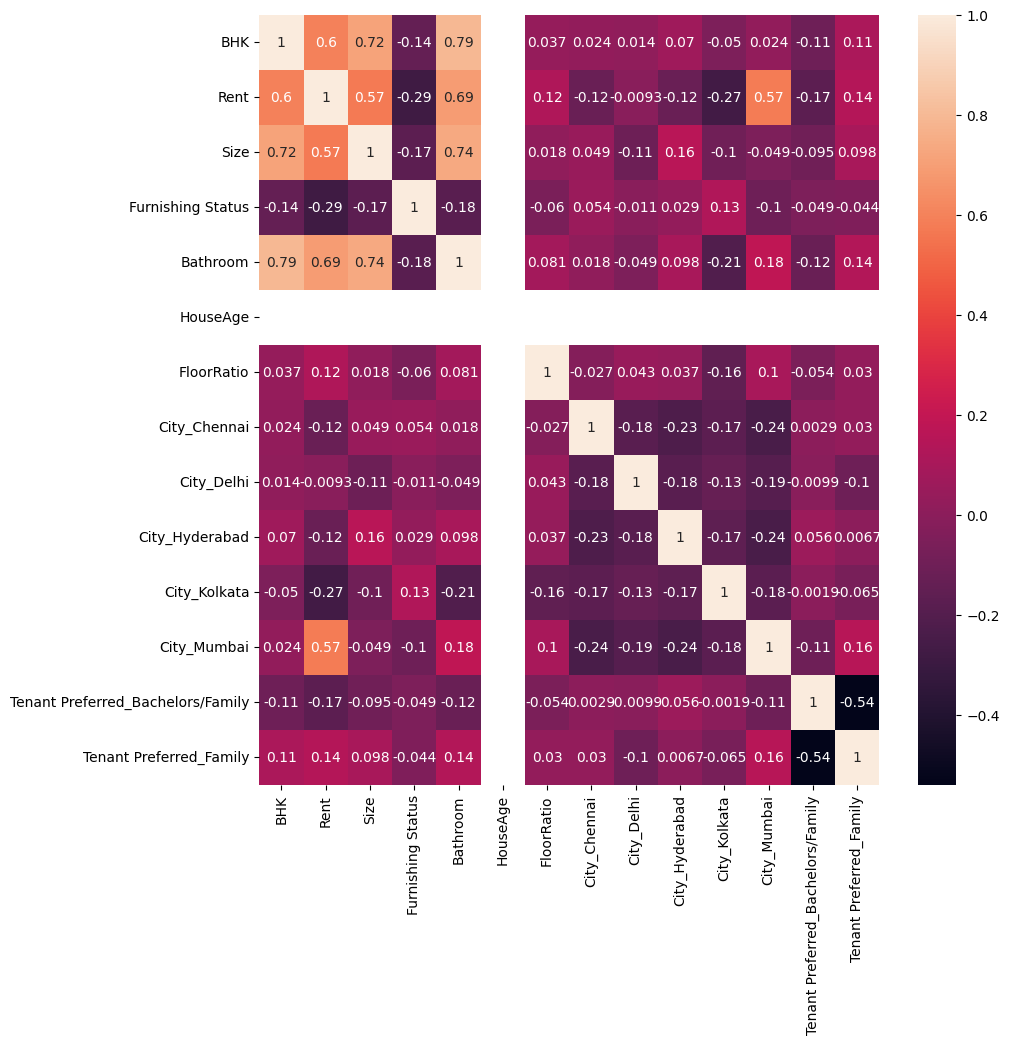

In [47]:
# correlation
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot= True)
plt.show()

In [48]:
x= df.drop("Rent", axis= 1)
y= df["Rent"]

In [49]:
# train-test-split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42)

In [50]:
print("Shape :", x_train.shape)
print("Dtype", x_train.dtypes)
print("Missing", np.isnan(x_train).sum())
print("Missing x_test", np.isnan(x_test).sum())
print("inf val", np.isinf(x_train).sum())
print("inf val x_test", np.isinf(x_test).sum())

Shape : (3796, 13)
Dtype BHK                                    int64
Size                                   int64
Furnishing Status                      int64
Bathroom                               int64
HouseAge                               int32
FloorRatio                           float64
City_Chennai                           int64
City_Delhi                             int64
City_Hyderabad                         int64
City_Kolkata                           int64
City_Mumbai                            int64
Tenant Preferred_Bachelors/Family      int64
Tenant Preferred_Family                int64
dtype: object
Missing BHK                                  0
Size                                 0
Furnishing Status                    0
Bathroom                             0
HouseAge                             0
FloorRatio                           0
City_Chennai                         0
City_Delhi                           0
City_Hyderabad                       0
City_Kolkata     

In [51]:
x_train.columns[np.isinf(x_train).any()]

Index([], dtype='object')

In [52]:
# feature scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [53]:
print(x_test)

[[-0.10773946  0.20927808  1.10912899 ... -0.50567406  0.61429512
  -0.33010414]
 [-0.10773946 -0.2631174  -1.81770705 ... -0.50567406  0.61429512
  -0.33010414]
 [-0.10773946 -0.70716914 -0.35428903 ...  1.97755844  0.61429512
  -0.33010414]
 ...
 [-0.10773946 -0.02691966  1.10912899 ... -0.50567406  0.61429512
  -0.33010414]
 [ 1.08461915  0.24864437 -0.35428903 ... -0.50567406  0.61429512
  -0.33010414]
 [-1.30009808 -0.73551287 -0.35428903 ... -0.50567406  0.61429512
  -0.33010414]]


In [54]:
# Implement ML Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [55]:
y_pred = model.predict(x_test)
print("Prediction", y_pred[:5])
print("Actual", y_test[:5].values)

Prediction [ 9.59676618  9.68935105 10.67220908 10.46596238 10.62045711]
Actual [ 9.6804065   9.39274526 10.2399955   8.98732181 10.73641841]


In [56]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
print("R2 Score", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score 0.8026534486185377
MAE 0.3180850601901443
MSE 0.17019261586086593
RMSE 0.41254407747641453


* The model achieved an R² score of 0.80, which means it explains approximately
80% of the variation in house prices.
* The MAE of 0.318 indicates that the average prediction error is relatively low.
* The RMSE is 0.413, which is only slightly higher than the MAE, suggesting there are no major outliers or large prediction errors.
* The MSE is also low, indicating that the model doesn't produce many extreme mistakes.
* Overall, these metrics suggest the model has good predictive performance and generalizes well to unseen data. If the target variable was normalized, the error metrics are in normalized units and would need to be inverse-transformed for interpretation in actual currency.




In [57]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

ds = DecisionTreeRegressor()
rf = RandomForestRegressor()
gb = GradientBoostingRegressor()
xg = XGBRegressor()

# ds.fit(x_train, y_train)
# ds.score(x_train, y_train)
rf.fit(x_train, y_train)
# gb.fit(x_train, y_train)
# xg.fit(x_train, y_train)

RandomForestRegressor()

In [58]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(score_func=f_regression, k=10)

X_new = selector.fit_transform(x, y)

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(x_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}


In [60]:
rf = RandomForestRegressor(max_depth=10, min_samples_leaf=4, n_estimators=200)
rf.fit(x_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=4, n_estimators=200)

In [61]:
rf.score(x_train, y_train)
rf.score(x_test, y_test)

0.8130442432743424

In [62]:
pred = rf.predict(x_test)

In [63]:
print("R2 Score", r2_score(y_test, pred))
print("MAE", mean_absolute_error(y_test, pred))
print("MSE", mean_squared_error(y_test, pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score 0.8130442432743424
MAE 0.31185186728393666
MSE 0.16123154453245853
RMSE 0.40153647970322515


In [66]:
import pickle

# Create a dictionary to hold all necessary objects
model_components = {
    'model': rf, # Your trained RandomForestClassifier model
    'scaler': sc, # Your fitted StandardScaler
    'encode': le # Your fitted LabelBinarizer
}

# Define the path to save the pickle file. Consider saving it in a Colab-accessible location.
pickle_file_path = r'C:\Users\dell\Downloads\House Price Prediction\house_price_model_and_preprocessors.pkl'

# Dump the dictionary into a pickle file
with open(pickle_file_path, 'wb') as f:
    pickle.dump(model_components, f)

print(f"All model components saved successfully to '{pickle_file_path}'")

All model components saved successfully to 'C:\Users\dell\Downloads\House Price Prediction\house_price_model_and_preprocessors.pkl'
